# IEEE-CIS Fraud Detection — Phase 6: Production Monitoring

## Goal
`models/lightgbm_production.pkl` is live. Phase 6 simulates what monitoring it in
production actually looks like — using `test_features.parquet` (506,691 rows, no
`isFraud` labels) as a stand-in for "new transactions we haven't seen the outcome
of yet."

## Why no performance metrics here
We can't compute precision/recall/AUC-PR — that needs ground-truth labels, and in
a real fraud system those arrive weeks later via chargebacks and disputes (this
delay is called **label latency**). So Phase 6 covers the two signals that *are*
available immediately, which is also why they matter most in practice — by the
time labels confirm a problem, the early-warning signals already caught it weeks
earlier:

1. **Prediction drift** — is the model's *output* distribution shifting?
2. **Feature drift** — are the model's *inputs* shifting?

Chapter 3 adds PSI (Population Stability Index) — the metric you'd actually be
asked to explain in a fraud/credit-risk interview, computed by hand instead of
read off a library.

In [7]:
import pandas as pd
import numpy as np
import joblib
import json
import os
import matplotlib.pyplot as plt

os.chdir('/Users/shaliqshukoor/fraud-risk-system')

train_df = pd.read_parquet('data/processed/train_features.parquet')
val_df   = pd.read_parquet('data/processed/val_features.parquet')
test_df  = pd.read_parquet('data/processed/test_features.parquet')

with open('data/processed/selected_feature_names.json') as f:
    selected_features = json.load(f)

production_model     = joblib.load('models/lightgbm_production.pkl')
label_encoders        = joblib.load('models/label_encoders.pkl')
production_artifacts  = joblib.load('models/feature_pipeline_artifacts.pkl')

with open('models/optimal_threshold.json') as f:
    threshold = json.load(f)['optimal_threshold']

print(f'train_df: {train_df.shape}')
print(f'val_df:   {val_df.shape}')
print(f'test_df:  {test_df.shape}')
print(f'Selected features: {len(selected_features)}')
print(f'Threshold: {threshold}')

train_df: (442905, 446)
val_df:   (147635, 446)
test_df:  (506691, 445)
Selected features: 410
Threshold: 0.16


## Chapter 1 — Prediction Drift

The "reference" distribution should be the exact in-sample data the production
model was trained on — `train_df + val_df`, with `email_target_encoded` and
`card4_6_target_encoded` refit on the full combined set (mirrors
`07_final_model_training.ipynb` Chapter 1 exactly, reusing the maps it already
computed and saved in `models/feature_pipeline_artifacts.pkl`).

We score that reference set and `test_df` with the same model and the same
`label_encoders.pkl` the live API uses, then compare the two predicted-probability
distributions. No labels required — this is the fastest signal available.

In [8]:
# Rebuild the exact in-sample training set the production model was fit on —
# mirrors notebooks/07_final_model_training.ipynb's Chapter 1, reusing the
# full-data target-encoding maps it already computed.
full_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
full_df['email_target_encoded'] = (
    full_df['P_emaildomain'].map(production_artifacts['email_fraud_map'])
    .fillna(production_artifacts['train_fraud_mean'])
)
full_df['card4_6_target_encoded'] = (
    full_df['card4_6'].map(production_artifacts['card_fraud_map'])
    .fillna(production_artifacts['train_fraud_mean'])
)


def score(df, model, encoders, features):
    """Mirrors api/model_loader.py's _build_row — same encoders, same
    unseen-category fallback — so this matches what the live API would predict."""
    X = df[features].copy()
    for col, le in encoders.items():
        values = X[col].astype(str)
        known = set(le.classes_)
        values = values.where(values.isin(known), le.classes_[0])
        X[col] = le.transform(values)
    return model.predict_proba(X)[:, 1]


ref_proba = score(full_df, production_model, label_encoders, selected_features)
cur_proba = score(test_df, production_model, label_encoders, selected_features)

print(f'Reference (train+val, in-sample): {len(ref_proba):,} predictions')
print(f'Current   (test, out-of-sample):  {len(cur_proba):,} predictions')

Reference (train+val, in-sample): 590,540 predictions
Current   (test, out-of-sample):  506,691 predictions


--- Predicted fraud-probability distribution ---
Reference mean: 0.1277  median: 0.0466
Current   mean: 0.1113  median: 0.0335

Reference flag rate (>= 0.16): 0.2248 (22.48%)
Current   flag rate (>= 0.16): 0.1998 (19.98%)
Relative change: -11.1%


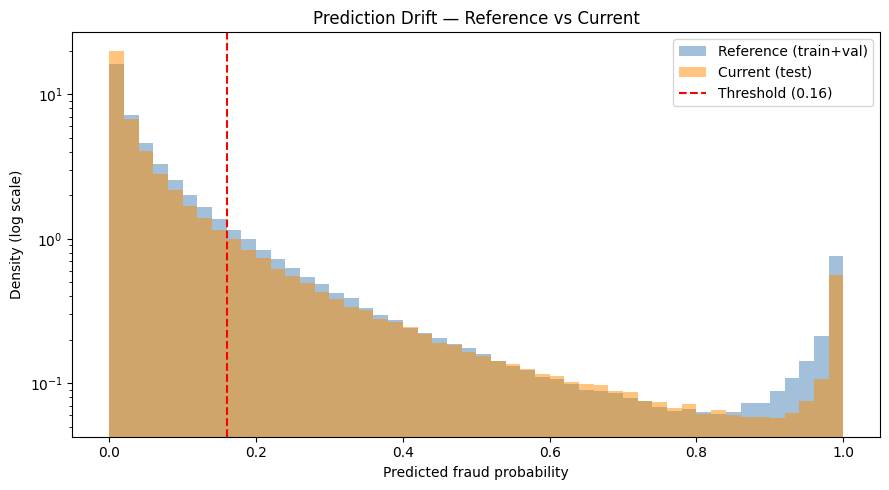

Saved to models/prediction_drift.png


In [9]:
ref_flag_rate = (ref_proba >= threshold).mean()
cur_flag_rate = (cur_proba >= threshold).mean()

print('--- Predicted fraud-probability distribution ---')
print(f'Reference mean: {ref_proba.mean():.4f}  median: {np.median(ref_proba):.4f}')
print(f'Current   mean: {cur_proba.mean():.4f}  median: {np.median(cur_proba):.4f}')
print()
print(f'Reference flag rate (>= {threshold}): {ref_flag_rate:.4f} ({ref_flag_rate*100:.2f}%)')
print(f'Current   flag rate (>= {threshold}): {cur_flag_rate:.4f} ({cur_flag_rate*100:.2f}%)')
print(f'Relative change: {(cur_flag_rate/ref_flag_rate - 1)*100:+.1f}%')

plt.figure(figsize=(9, 5))
plt.hist(ref_proba, bins=50, alpha=0.5, density=True, label='Reference (train+val)', color='steelblue')
plt.hist(cur_proba, bins=50, alpha=0.5, density=True, label='Current (test)', color='darkorange')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel('Predicted fraud probability')
plt.ylabel('Density (log scale)')
plt.title('Prediction Drift — Reference vs Current')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.savefig('models/prediction_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to models/prediction_drift.png')

**Finding**: predicted fraud probability shifted down ~11% (flag rate 22.5% → 20.0%) — a broad, gradual shift across the whole distribution, not a new cluster appearing. Consistent with population drift, not model breakage.

## Chapter 2 — Feature Drift (Evidently AI)

`DataDriftPreset` runs an automatic per-column statistical test — KS-test for
numeric columns, a Z-test for categorical ones — comparing `test_df` against
`full_df` (train+val combined, with target encodings refit on the full set —
built in Chapter 1), across the 410 selected features, plus an overall "how many
columns drifted" verdict.



In [10]:
from evidently import Report, Dataset, DataDefinition
from evidently.presets import DataDriftPreset

drift_cols = [c for c in selected_features if c in full_df.columns and c in test_df.columns]

ref_ds = Dataset.from_pandas(full_df[drift_cols], data_definition=DataDefinition())
cur_ds = Dataset.from_pandas(test_df[drift_cols], data_definition=DataDefinition())

report = Report([DataDriftPreset()])
snapshot = report.run(cur_ds, ref_ds)

snapshot.save_html('models/drift_report.html')
print('Saved full interactive report to models/drift_report.html')

result = snapshot.dict()
overall = next(m for m in result['metrics'] if m['metric_name'].startswith('DriftedColumnsCount'))
print(f"\nOverall: {overall['value']['count']:.0f} / {len(drift_cols)} columns drifted "
      f"({overall['value']['share']*100:.1f}%)")

drift_rows = [
    {'feature': m['config']['column'], 'p_value': m['value']}
    for m in result['metrics'] if m['metric_name'].startswith('ValueDrift')
]
drift_df = pd.DataFrame(drift_rows).sort_values('p_value')
drift_df['drifted'] = drift_df['p_value'] < 0.05

print('\nTop 15 most-drifted features (lowest p-value = strongest drift signal):')
print(drift_df.head(15).to_string(index=False))

Saved full interactive report to models/drift_report.html

Overall: 63 / 410 columns drifted (15.4%)

Top 15 most-drifted features (lowest p-value = strongest drift signal):
      feature  p_value  drifted
   is_outlier 0.000735     True
hour_is_risky 0.002004     True
           V8 0.003565     True
         V186 0.005226     True
         V284 0.005245     True
         V147 0.005358     True
         V288 0.005463     True
        id_25 0.006498     True
         V161 0.006563     True
         V270 0.006610     True
        id_23 0.006737     True
         V196 0.006794     True
        id_08 0.006845     True
        id_14 0.007255     True
         V249 0.007395     True


**Finding**: 63/410 columns (15.4%) flagged as drifted — but with ~590K vs ~506K rows, KS/Z-tests flag almost any real difference as statistically significant regardless of size, so this number alone overstates practical concern. PSI (Chapter 3) is the real read.

## Chapter 3 — Manual PSI (Population Stability Index)

Evidently's test tells you *whether* a column drifted, not *how much* — and PSI
is the metric that actually gets quoted in fraud/credit-risk interviews. The
formula: bucket the reference distribution into deciles, compare what fraction
of each dataset falls in each bucket:

`PSI = Σ (current% - reference%) × ln(current% / reference%)`

Standard interpretation bands: **< 0.1** stable, **0.1–0.25** moderate shift
(watch), **> 0.25** significant shift (investigate/retrain).

Reference is `full_df` here too, same reasoning as Chapter 2 — it's the actual
data the production model trained on, so every feature (including the two
target-encoded ones) can be compared consistently.

A feature can come back `NaN` if it has too few distinct values to split into
deciles meaningfully (e.g. a 3-valued ordinal flag) — that's the function
declining to compute a number, not a missing result.

               feature          psi
                   D15 2.537542e-01
                    C1 2.255075e-02
  email_target_encoded 6.101420e-03
                    C8 4.879999e-03
        TransactionAmt 4.020979e-03
                    D2 3.925080e-03
                 card2 3.632169e-03
                   C14 3.393163e-03
card4_6_target_encoded 2.105738e-03
                 addr1 1.739449e-03
                 card1 1.399833e-03
                   C13 9.343054e-04
                   V70 3.130853e-04
                  V258 1.883097e-07
            M4_encoded          NaN


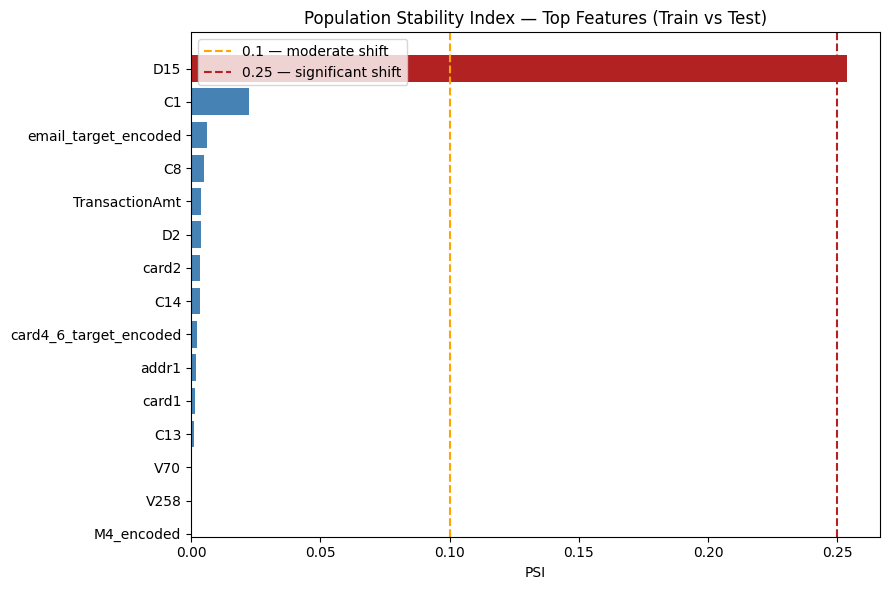

Saved to models/psi_scores.png


In [11]:
def psi(reference: pd.Series, current: pd.Series, bins: int = 10) -> float:
    """Population Stability Index, bucketed on the reference distribution's deciles."""
    reference = reference.dropna()
    current = current.dropna()
    quantiles = np.unique(np.quantile(reference, np.linspace(0, 1, bins + 1)))
    if len(quantiles) < 3:
        return np.nan  # not enough distinct values to bucket meaningfully

    ref_counts, _ = np.histogram(reference, bins=quantiles)
    cur_counts, _ = np.histogram(current, bins=quantiles)

    ref_pct = np.clip(ref_counts / len(reference), 1e-4, None)
    cur_pct = np.clip(cur_counts / len(current), 1e-4, None)

    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))


# Top features by model importance (notebooks/04_hyperparameter_tuning.ipynb
# Chapter 4) that are numeric — PSI's quantile bucketing needs numeric columns,
# so M4_encoded (the ordinal version) stands in for raw M4 here.
top_features = [
    'V258', 'C14', 'card1', 'TransactionAmt', 'D2', 'card2', 'C8', 'addr1',
    'C1', 'C13', 'card4_6_target_encoded', 'V70', 'D15', 'email_target_encoded', 'M4_encoded',
]
top_features = [f for f in top_features if f in full_df.columns and f in test_df.columns]

psi_scores = {f: psi(full_df[f], test_df[f]) for f in top_features}
psi_df = pd.DataFrame(psi_scores.items(), columns=['feature', 'psi']).sort_values('psi', ascending=False)
print(psi_df.to_string(index=False))

plt.figure(figsize=(9, 6))
colors = ['firebrick' if v > 0.25 else 'orange' if v > 0.1 else 'steelblue' for v in psi_df['psi']]
plt.barh(psi_df['feature'][::-1], psi_df['psi'][::-1], color=colors[::-1])
plt.axvline(0.1, color='orange', linestyle='--', label='0.1 — moderate shift')
plt.axvline(0.25, color='firebrick', linestyle='--', label='0.25 — significant shift')
plt.xlabel('PSI')
plt.title('Population Stability Index — Top Features (Train vs Test)')
plt.legend()
plt.tight_layout()
plt.savefig('models/psi_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to models/psi_scores.png')

**Finding**: only `D15` crosses the significant-shift threshold (PSI 0.254); everything else — including the now-fixed `email_target_encoded`/`card4_6_target_encoded` — is well under 0.1. `D15` is a time-delta feature, so this is plausibly just time passing rather than a real fraud-pattern change.

## Conclusion

This notebook is the monitoring layer the rest of the pipeline feeds into:

- **Prediction drift** (Chapter 1) is the cheapest, fastest signal — pure model
  output comparison, zero labels needed. In production this would run on every
  new batch (or streaming window) of scored transactions.
- **Feature drift** (Chapters 2–3) explains *why* prediction drift happened, if
  it did — which specific inputs shifted.
- **What's still missing**: true performance metrics, which need the labels that
  won't arrive for weeks (chargebacks, disputes). Those get tracked separately,
  on a delay, refining past estimates as labels mature.

**Where this goes next (Phase 10 — Airflow)**: a DAG would run this exact
PSI/drift check on a schedule, and if any feature crosses the 0.25 threshold (or
the overall Evidently drift share exceeds some bar), it triggers the retrain
pipeline automatically — `build_features.py`'s `fit_pipeline()` on fresh labeled
data, retrain, evaluate against quality gates, then redeploy. That's the
automated version of the leak-fix-and-redeploy cycle done by hand this session.